In [2]:
import sys
!{sys.executable} -m pip install polars pandas numpy matplotlib seaborn scikit-learn pyarrow psutil

   ---------------------------------------- 0.0/833.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/833.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/833.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/833.4 kB ? eta -:--:--
   ------------ --------------------------- 262.1/833.4 kB ? eta -:--:--
   ------------------------------------- -- 786.4/833.4 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 833.4/833.4 kB 1.9 MB/s  0:00:01
   ---------------------------------------- 0.0/52.0 MB ? eta -:--:--
   - -------------------------------------- 1.3/52.0 MB 5.3 MB/s eta 0:00:10
   - -------------------------------------- 1.6/52.0 MB 4.9 MB/s eta 0:00:11
   - -------------------------------------- 2.4/52.0 MB 3.8 MB/s eta 0:00:14
   -- ------------------------------------- 3.1/52.0 MB 3.5 MB/s eta 0:00:14
   -- ------------------------------------- 3.7/52.0 MB 3.4 MB/s eta 0:00:15
   ---- -----------------------

In [6]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(15)

UMBRAL_RETRASO = 15  # minutos: vuelo "retrasado" si ARRIVAL_DELAY > 15

RUTA_DATOS = Path(r"E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 5\Tarea_3\data\raw")
print("RUTA_DATOS:", RUTA_DATOS)

RUTA_DATOS: E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 5\Tarea_3\data\raw


In [7]:
df = pl.read_csv(
    str(RUTA_DATOS / "flights.csv"),
    null_values=["", "NA"],
    infer_schema_length=10000,
)
print(f"Dimensiones: {df.height:,} filas x {df.width} columnas")

Dimensiones: 5,819,079 filas x 31 columnas


In [8]:
print("--- Esquema (tipos de datos) ---")
for nombre, tipo in df.schema.items():
    print(f"  {nombre:<22} {tipo}")

df.head(5)

--- Esquema (tipos de datos) ---
  YEAR                   Int64
  MONTH                  Int64
  DAY                    Int64
  DAY_OF_WEEK            Int64
  AIRLINE                String
  FLIGHT_NUMBER          Int64
  TAIL_NUMBER            String
  ORIGIN_AIRPORT         String
  DESTINATION_AIRPORT    String
  SCHEDULED_DEPARTURE    Int64
  DEPARTURE_TIME         Int64
  DEPARTURE_DELAY        Int64
  TAXI_OUT               Int64
  WHEELS_OFF             Int64
  SCHEDULED_TIME         Int64
  ELAPSED_TIME           Int64
  AIR_TIME               Int64
  DISTANCE               Int64
  WHEELS_ON              Int64
  TAXI_IN                Int64
  SCHEDULED_ARRIVAL      Int64
  ARRIVAL_TIME           Int64
  ARRIVAL_DELAY          Int64
  DIVERTED               Int64
  CANCELLED              Int64
  CANCELLATION_REASON    String
  AIR_SYSTEM_DELAY       Int64
  SECURITY_DELAY         Int64
  AIRLINE_DELAY          Int64
  LATE_AIRCRAFT_DELAY    Int64
  WEATHER_DELAY          Int64


YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,…,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
i64,i64,i64,i64,str,i64,str,…,i64,str,i64,i64,i64,i64,i64
2015,1,1,4,"""AS""",98,"""N407AS""",…,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",2336,"""N3KUAA""",…,0,null,null,null,null,null,null
2015,1,1,4,"""US""",840,"""N171US""",…,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",258,"""N3HYAA""",…,0,null,null,null,null,null,null
2015,1,1,4,"""AS""",135,"""N527AS""",…,0,null,null,null,null,null,null


In [9]:
# RETRASADO: 1 si el retraso de llegada supera el umbral, 0 si no.
# Queda nulo en vuelos cancelados/desviados (sin ARRIVAL_DELAY).
df = df.with_columns(
    (pl.col("ARRIVAL_DELAY") > UMBRAL_RETRASO).cast(pl.Int8).alias("RETRASADO")
)

dist_objetivo = (
    df.group_by("RETRASADO")
      .agg(pl.len().alias("conteo"))
      .with_columns((pl.col("conteo") / df.height * 100).round(2).alias("porcentaje"))
      .sort("RETRASADO")
)
print("Distribución de la variable objetivo:")
dist_objetivo

Distribución de la variable objetivo:


RETRASADO,conteo,porcentaje
i8,u32,f64
null,105071,1.81
0,4690510,80.61
1,1023498,17.59


In [10]:
df.describe()

statistic,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,…,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,RETRASADO
str,f64,f64,f64,f64,str,f64,…,str,f64,f64,f64,f64,f64,f64
"""count""",5.819079e6,5.819079e6,5.819079e6,5.819079e6,"""5819079""",5.819079e6,…,"""89884""",1.063439e6,1.063439e6,1.063439e6,1.063439e6,1.063439e6,5.714008e6
"""null_count""",0.0,0.0,0.0,0.0,"""0""",0.0,…,"""5729195""",4.75564e6,4.75564e6,4.75564e6,4.75564e6,4.75564e6,105071.0
"""mean""",2015.0,6.524085,15.704594,3.926941,null,2173.092742,…,null,13.480568,0.076154,18.969547,23.472838,2.91529,0.179121
"""std""",0.0,3.405137,8.783425,1.988845,null,1757.063999,…,null,28.003679,2.14346,48.161642,43.197018,20.433336,0.383454
"""min""",2015.0,1.0,1.0,1.0,"""AA""",1.0,…,"""A""",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",2015.0,4.0,8.0,2.0,null,730.0,…,null,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",2015.0,7.0,16.0,4.0,null,1690.0,…,null,2.0,0.0,2.0,3.0,0.0,0.0
"""75%""",2015.0,9.0,23.0,6.0,null,3230.0,…,null,18.0,0.0,19.0,29.0,0.0,0.0
"""max""",2015.0,12.0,31.0,7.0,"""WN""",9855.0,…,"""D""",1134.0,573.0,1971.0,1331.0,1211.0,1.0


In [11]:
nulos = (
    df.null_count()
      .transpose(include_header=True, header_name="columna", column_names=["n_nulos"])
      .with_columns((pl.col("n_nulos") / df.height * 100).round(2).alias("pct_nulos"))
      .filter(pl.col("n_nulos") > 0)
      .sort("n_nulos", descending=True)
)
print("Columnas con valores faltantes:")
nulos

Columnas con valores faltantes:


columna,n_nulos,pct_nulos
str,u32,f64
"""CANCELLATION_REASON""",5729195,98.46
"""AIR_SYSTEM_DELAY""",4755640,81.72
"""SECURITY_DELAY""",4755640,81.72
"""AIRLINE_DELAY""",4755640,81.72
"""LATE_AIRCRAFT_DELAY""",4755640,81.72
"""WEATHER_DELAY""",4755640,81.72
"""ELAPSED_TIME""",105071,1.81
"""AIR_TIME""",105071,1.81
"""ARRIVAL_DELAY""",105071,1.81


#  Carpeta de figuras + distribución del target

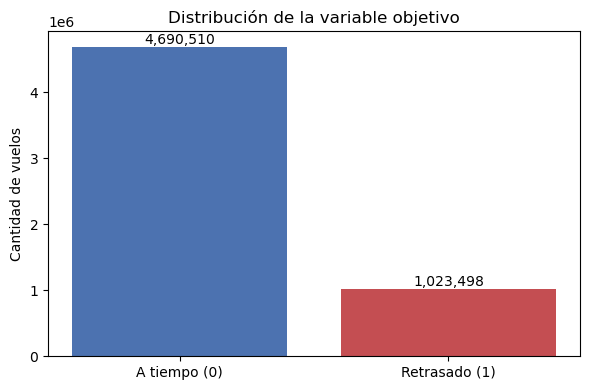

In [12]:
RUTA_FIGURAS = RUTA_DATOS.parent.parent / "figures"   # .../Tarea_3/figures
RUTA_FIGURAS.mkdir(exist_ok=True)

dist = (df.filter(pl.col("RETRASADO").is_not_null())
          .group_by("RETRASADO").agg(pl.len().alias("conteo")).sort("RETRASADO"))
etiquetas = ["A tiempo (0)", "Retrasado (1)"]
valores = dist["conteo"].to_list()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(etiquetas, valores, color=["#4C72B0", "#C44E52"])
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de vuelos")
for i, v in enumerate(valores):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "01_distribucion_target.png", dpi=120)
plt.show()

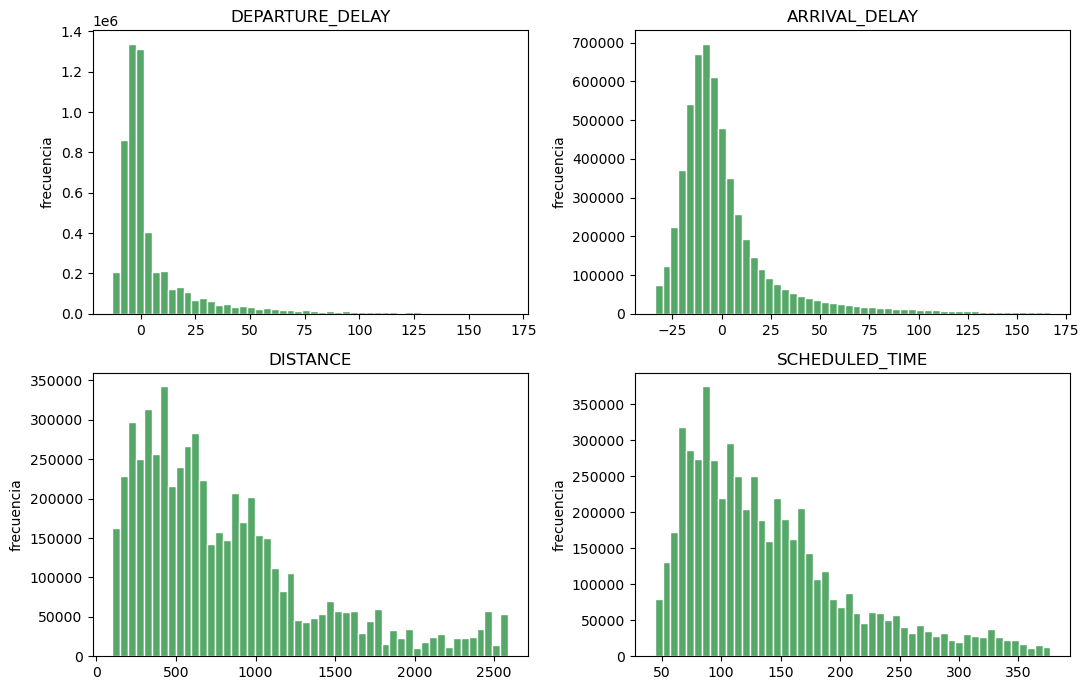

In [13]:
cols_hist = ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "DISTANCE", "SCHEDULED_TIME"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), cols_hist):
    datos = df.select(pl.col(c)).drop_nulls().to_series().to_numpy()
    lo, hi = np.percentile(datos, [1, 99])          # recorte de outliers para visualizar
    ax.hist(datos[(datos >= lo) & (datos <= hi)], bins=50,
            color="#55A868", edgecolor="white")
    ax.set_title(c); ax.set_ylabel("frecuencia")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "02_histogramas.png", dpi=120)
plt.show()

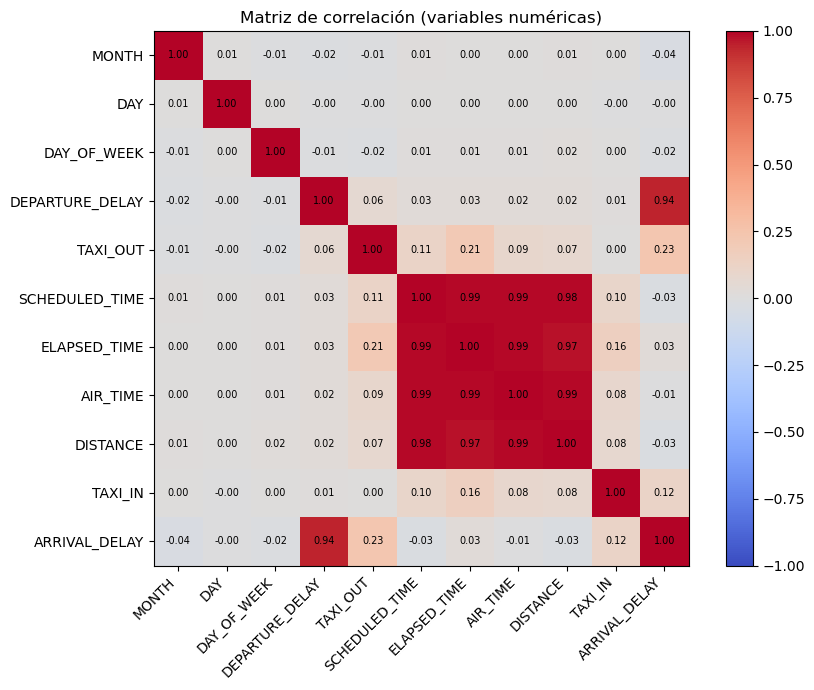

In [14]:
cols_num = ["MONTH", "DAY", "DAY_OF_WEEK", "DEPARTURE_DELAY", "TAXI_OUT",
            "SCHEDULED_TIME", "ELAPSED_TIME", "AIR_TIME", "DISTANCE",
            "TAXI_IN", "ARRIVAL_DELAY"]

# drop_nulls antes de correlacionar: Polars propaga nulos a nan si no se limpian
corr = df.select(cols_num).drop_nulls().corr()
M = corr.to_numpy()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_num))); ax.set_xticklabels(cols_num, rotation=45, ha="right")
ax.set_yticks(range(len(cols_num))); ax.set_yticklabels(cols_num)
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im); ax.set_title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "03_correlacion.png", dpi=120)
plt.show()

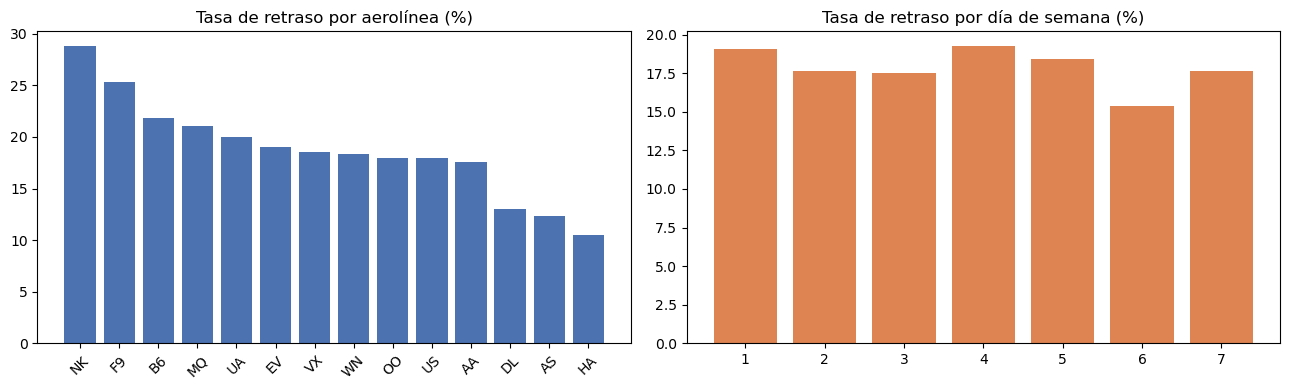

Aerolíneas con mayor tasa de retraso:


AIRLINE,tasa,n
str,f64,u32
"""NK""",0.287917,115193
"""F9""",0.253646,90090
"""B6""",0.218503,262042
"""MQ""",0.210276,278791
"""UA""",0.199509,507762


In [15]:
def tasa_por(col):
    return (df.filter(pl.col("RETRASADO").is_not_null())
              .group_by(col)
              .agg(pl.col("RETRASADO").mean().alias("tasa"), pl.len().alias("n")))

t_air = tasa_por("AIRLINE").sort("tasa", descending=True)
t_dow = tasa_por("DAY_OF_WEEK").sort("DAY_OF_WEEK")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(t_air["AIRLINE"].to_list(), (t_air["tasa"] * 100).to_list(), color="#4C72B0")
axes[0].set_title("Tasa de retraso por aerolínea (%)"); axes[0].tick_params(axis="x", rotation=45)
axes[1].bar([str(d) for d in t_dow["DAY_OF_WEEK"].to_list()],
            (t_dow["tasa"] * 100).to_list(), color="#DD8452")
axes[1].set_title("Tasa de retraso por día de semana (%)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "04_tasa_por_categoria.png", dpi=120)
plt.show()

print("Aerolíneas con mayor tasa de retraso:")
t_air.head(5)

# Filtrado, nulos y columnas con fuga

In [16]:
# Fuga de datos: se conocen DURANTE o DESPUÉS del vuelo (no disponibles al predecir)
COLS_FUGA = ["ARRIVAL_DELAY", "ELAPSED_TIME", "AIR_TIME", "ARRIVAL_TIME", "WHEELS_ON",
             "TAXI_IN", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
             "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY", "CANCELLATION_REASON",
             "DIVERTED", "CANCELLED"]
# Identificadores y constantes sin valor predictivo
COLS_ID = ["YEAR", "FLIGHT_NUMBER", "TAIL_NUMBER", "DEPARTURE_TIME", "WHEELS_OFF"]

In [17]:
n0 = df.height

# 1) Quitar cancelados/desviados (RETRASADO nulo)
df_fe = df.filter(pl.col("RETRASADO").is_not_null())
print(f"Tras quitar cancelados/desviados: {df_fe.height:,} ({n0 - df_fe.height:,} eliminados)")

# 2) Eliminar columnas con fuga e identificadores
df_fe = df_fe.drop(COLS_FUGA + COLS_ID)

# 3) Eliminar nulos residuales en variables clave
df_fe = df_fe.drop_nulls(subset=["DEPARTURE_DELAY", "TAXI_OUT", "SCHEDULED_TIME"])
print(f"Dimensiones tras limpieza: {df_fe.height:,} filas x {df_fe.width} columnas")

Tras quitar cancelados/desviados: 5,714,008 (105,071 eliminados)
Dimensiones tras limpieza: 5,714,008 filas x 13 columnas


In [18]:
df_fe = df_fe.with_columns([
    (pl.col("SCHEDULED_DEPARTURE") // 100).clip(0, 23).alias("HORA_SALIDA"),  # HHMM -> hora
    ((pl.col("MONTH") - 1) // 3 + 1).alias("TRIMESTRE"),
    pl.col("DAY_OF_WEEK").is_in([6, 7]).cast(pl.Int8).alias("ES_FIN_SEMANA"),
])

# Periodo del día a partir de la hora de salida
df_fe = df_fe.with_columns(
    pl.when(pl.col("HORA_SALIDA") < 6).then(pl.lit("madrugada"))
      .when(pl.col("HORA_SALIDA") < 12).then(pl.lit("mañana"))
      .when(pl.col("HORA_SALIDA") < 18).then(pl.lit("tarde"))
      .otherwise(pl.lit("noche")).alias("PERIODO_DIA")
)
print("Features creadas: HORA_SALIDA, TRIMESTRE, ES_FIN_SEMANA, PERIODO_DIA")

Features creadas: HORA_SALIDA, TRIMESTRE, ES_FIN_SEMANA, PERIODO_DIA


In [19]:
airlines = (pl.read_csv(str(RUTA_DATOS / "airlines.csv"))
              .rename({"AIRLINE": "AEROLINEA_NOMBRE"}))

df_fe = df_fe.join(airlines, left_on="AIRLINE", right_on="IATA_CODE", how="left")
print("Join con airlines OK | nulos en nombre:", df_fe["AEROLINEA_NOMBRE"].null_count())

Join con airlines OK | nulos en nombre: 0


In [20]:
# Congestión del aeropuerto de origen como proxy (más tráfico -> más retrasos).
# No usa el target, así que no introduce fuga de datos.
vuelos_origen = (df_fe.group_by("ORIGIN_AIRPORT")
                       .agg(pl.len().alias("VUELOS_ORIGEN")))

df_fe = df_fe.join(vuelos_origen, on="ORIGIN_AIRPORT", how="left")
print("group_by + join VUELOS_ORIGEN OK | rango:",
      df_fe["VUELOS_ORIGEN"].min(), "-", df_fe["VUELOS_ORIGEN"].max())

group_by + join VUELOS_ORIGEN OK | rango: 4 - 343506


In [21]:
RUTA_PROC = RUTA_DATOS.parent / "processed"
RUTA_PROC.mkdir(exist_ok=True)
df_fe.write_parquet(RUTA_PROC / "vuelos_features.parquet")

print(f"df_fe final: {df_fe.height:,} filas x {df_fe.width} columnas")
print("Columnas:", df_fe.columns)
df_fe.head()

df_fe final: 5,714,008 filas x 19 columnas
Columnas: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'RETRASADO', 'HORA_SALIDA', 'TRIMESTRE', 'ES_FIN_SEMANA', 'PERIODO_DIA', 'AEROLINEA_NOMBRE', 'VUELOS_ORIGEN']


MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,…,RETRASADO,HORA_SALIDA,TRIMESTRE,ES_FIN_SEMANA,PERIODO_DIA,AEROLINEA_NOMBRE,VUELOS_ORIGEN
i64,i64,i64,str,str,str,i64,…,i8,i64,i64,i8,str,str,u32
1,1,4,"""AS""","""ANC""","""SEA""",5,…,0,0,1,0,"""madrugada""","""Alaska Airlines Inc.""",15818
1,1,4,"""AA""","""LAX""","""PBI""",10,…,0,0,1,0,"""madrugada""","""American Airlines Inc.""",192003
1,1,4,"""US""","""SFO""","""CLT""",20,…,0,0,1,0,"""madrugada""","""US Airways Inc.""",145491
1,1,4,"""AA""","""LAX""","""MIA""",20,…,0,0,1,0,"""madrugada""","""American Airlines Inc.""",192003
1,1,4,"""AS""","""SEA""","""ANC""",25,…,0,0,1,0,"""madrugada""","""Alaska Airlines Inc.""",110178


# Preprocesamiento

In [22]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

RUTA_RESULTADOS = RUTA_DATOS.parent.parent / "results"
RUTA_RESULTADOS.mkdir(exist_ok=True)

# Cargar el dataset con features (re-ejecutable de forma independiente)
df_fe = pl.read_parquet(RUTA_DATOS.parent / "processed" / "vuelos_features.parquet")

COLS_NUM = ["MONTH", "DAY", "DAY_OF_WEEK", "DEPARTURE_DELAY", "TAXI_OUT", "SCHEDULED_TIME",
            "DISTANCE", "HORA_SALIDA", "TRIMESTRE", "ES_FIN_SEMANA", "VUELOS_ORIGEN"]
COLS_CAT = ["AIRLINE", "PERIODO_DIA"]   # baja cardinalidad -> one-hot

# One-hot encoding con Polars y matriz X / vector y
df_model = (df_fe.select(COLS_NUM + COLS_CAT + ["RETRASADO"])
                  .to_dummies(columns=COLS_CAT, drop_first=True))
y = df_model["RETRASADO"].to_numpy()
X = df_model.drop("RETRASADO").to_numpy().astype(np.float32)   # float32: ahorra memoria
nombres_features = [c for c in df_model.columns if c != "RETRASADO"]
print(f"X: {X.shape} | clase positiva: {y.mean()*100:.2f} %")

# División train/test estratificada
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado SOLO para la regresión logística (los árboles no lo requieren)
escalador = StandardScaler()
X_tr_sc = escalador.fit_transform(X_tr).astype(np.float32)
X_te_sc = escalador.transform(X_te).astype(np.float32)
print("Train:", X_tr.shape, "| Test:", X_te.shape)

X: (5714008, 27) | clase positiva: 17.91 %
Train: (4571206, 27) | Test: (1142802, 27)


In [24]:
modelos = {
    "Regresión Logística":      (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Random Forest":            (RandomForestClassifier(n_estimators=50, max_depth=20, n_jobs=-1,
                                     class_weight="balanced", max_samples=0.5, random_state=42), False),
    "Gradient Boosting (Hist)": (HistGradientBoostingClassifier(max_iter=200, class_weight="balanced",
                                     random_state=42), False),
}

resultados, ajustados = [], {}
for nombre, (modelo, escalar) in modelos.items():
    Xtr, Xte = (X_tr_sc, X_te_sc) if escalar else (X_tr, X_te)
    t0 = time.perf_counter()
    modelo.fit(Xtr, y_tr)
    t_entren = time.perf_counter() - t0

    proba = modelo.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    resultados.append({
        "modelo": nombre,
        "t_entren_s": round(t_entren, 2),
        "accuracy": round(accuracy_score(y_te, pred), 4),
        "f1": round(f1_score(y_te, pred), 4),
        "auc": round(roc_auc_score(y_te, proba), 4),
    })
    ajustados[nombre] = (modelo, pred)
    print(f"{nombre:<26} listo en {t_entren:6.2f}s")

Regresión Logística        listo en  17.69s
Random Forest              listo en 301.98s
Gradient Boosting (Hist)   listo en 126.47s


In [25]:
tabla = pl.DataFrame(resultados).sort("auc", descending=True)
tabla.write_csv(RUTA_RESULTADOS / "comparacion_modelos.csv")
tabla

modelo,t_entren_s,accuracy,f1,auc
str,f64,f64,f64,f64
"""Gradient Boosting (Hist)""",126.47,0.9314,0.8242,0.9719
"""Random Forest""",301.98,0.9436,0.8448,0.9701
"""Regresión Logística""",17.69,0.9257,0.812,0.9653


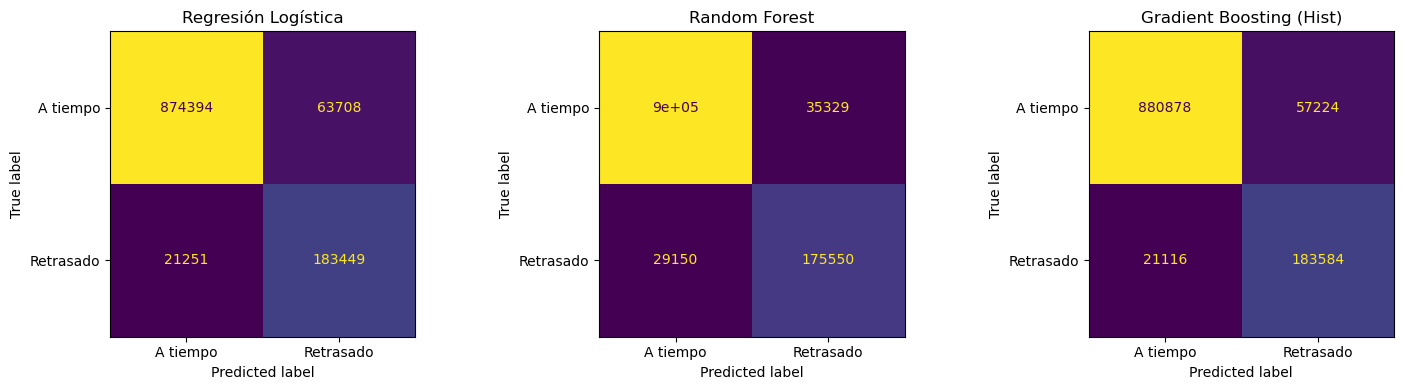

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, (modelo, pred)) in zip(axes, ajustados.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred),
                           display_labels=["A tiempo", "Retrasado"]).plot(ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "05_matrices_confusion.png", dpi=120)
plt.show()

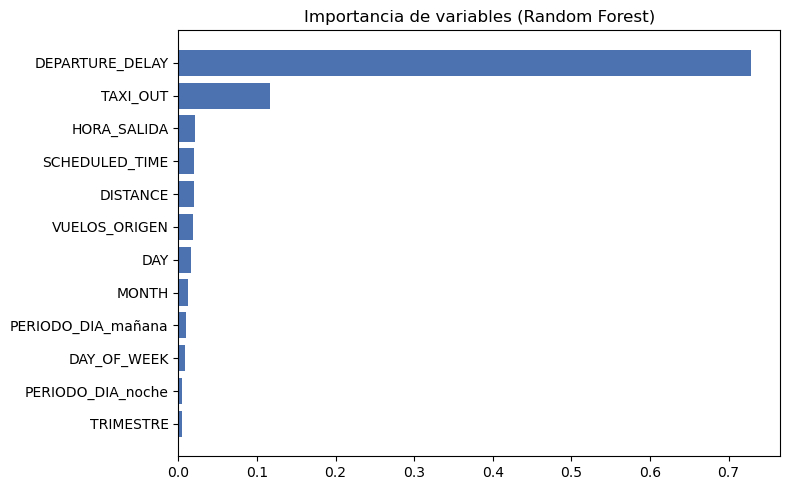

In [27]:
rf = ajustados["Random Forest"][0]
imp = (pl.DataFrame({"feature": nombres_features, "importancia": rf.feature_importances_})
         .sort("importancia", descending=True).head(12))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"].to_list()[::-1], imp["importancia"].to_list()[::-1], color="#4C72B0")
ax.set_title("Importancia de variables (Random Forest)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "06_importancia_variables.png", dpi=120)
plt.show()